## 🏔️ MIMO Channel Denoising (Final Competition)

This assignment is the **final homework of the course**. In the previous homework, we studied channel estimation using least-squares (LS) methods and observed that LS estimation produces noisy channel estimates. To partially mitigate this problem, we applied **hard-window filtering in the delay domain**, which exploits the limited delay spread of wireless channels. This method will be provided here as a **baseline algorithm**.

Unlike previous assignments, this task **does not have a predefined optimal solution**. Your objective is to design an algorithm that improves the quality of the estimated channel. You are free to use any method that exploits the structural properties of MIMO channels discussed throughout the course, such as: sparsity in the delay or angular domains, low-rank structure, spatial correlation and so on.

Students are encouraged to explore **recent scientific literature** and implement or adapt modern algorithms proposed in research papers.


### 🎯 Learning Objectives

By completing this assignment, you will:

1. Analyze link-level performance metrics of MIMO systems, such as **capacity** or **spectral efficiency**.
2. Study the influence of channel estimation noise on **SVD-based precoding performance**.
3. Search for and analyze **recent research literature** related to channel estimation or denoising in MIMO systems.
4. Develop a clear **technical justification** for the chosen algorithmic approach.
5. Implement and evaluate an improved channel denoising method.


### Implementation Guidelines

You are free to reuse and modify code provided in this homework and from previous homeworks. 
If you decide to use **AI-based methods**, you must carefully address the **overfitting problem**. In particular:
- the model should generalize to unseen channel realizations,
- training and evaluation datasets must be clearly separated.

If additional training data is required, you may generate new channel realizations or request assistance from the instructor team.

> ⚠️ Note: The goal of this assignment is not only to achieve the best performance, but also to **demonstrate understanding of MIMO channel structure and algorithm design principles**.

In [32]:
import os
import scipy
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange
from numpy import sqrt
plt.rcParams.update({'font.size': 15})

USE_GOOGLE_DRIVE = False
FOLDER_PATH = r'C:\Users\Lenovo\Desktop\MIMO\Files\\' 

# Which channel file you'd like to load
CHAN_NAME = 'link_chan_{}.mat'.format('SPEED')                                  #  <<< Set your value here

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/gdrive')
    CHAN_NAME = 'link_chan_{}.mat'.format('SPEED')

os.chdir(FOLDER_PATH)

###  Channel structure and already implemented code
Let us load one of the `.mat` channel file and examine its shape. 

The ground true MIMO channel is represented as a complex-valued, high-dimentional tensor:
$$\mathcal{H} \in \mathbb{C}^{M \times N \times K \times T},$$
where:
- $M - $Number of antennas at the user equipment (UE) side (4),
- $N - $Number of antennas at the base station (BS) side (64),
- $K - $Number of OFDM subcarriers used for data transmission (600),
- $T - $Number of time instants at which the channel was measured (100).

In [33]:
H = scipy.io.loadmat(FOLDER_PATH+CHAN_NAME)['Link_Channel']
H = H.transpose(3,2,0,1)

N_tti, N_subcarriers, N_ue_ants, N_bs_ants = H.shape

Also we need `get_noise`, `normalize` and `get_svd_precoder` functions based on previous homewoks

In [34]:
print(H.shape)
np.random.seed(42)

(100, 600, 4, 64)


In [35]:
def get_noise(signal, SNR_dB):
    ''' Returns complex AWGN tensor for a signal with the same shape
    :param signal: (np.ndarray) some signal array with shape of (100, 600, 4, 64)
    :param SNR_dB: (int | None) SNR value in decibels, which adjusts noise power. 
                    if SNR is None, return 0 (no noise at all)
    :return: complex AWGN tensor
    '''
    
    if SNR_dB is None:
        return 0
    
    # complex-valued AWGN with 0 mean and unit variance with same size as @signal
    noise = np.sqrt(1/2) * (np.random.randn(*signal.shape) + 1j*np.random.randn(*signal.shape))
    
    # Calculate mean signal power
    P_signal = np.mean(np.abs(signal)**2, axis = (-1,-2,-3), keepdims = True)

    # Normalize Noise to satisfy SNR
    noise_normed = noise * sqrt(10**(-SNR_dB/10) * P_signal)
    return noise_normed


def normalize(H):
    '''
    Normalizes the channel along UE antennas and subcarriers to have unit power on each receive antenna.
    Inputs: 
        - H: (np.ndarray) the channel array with shape (100, 600, 4, 64)
    Outputs:
        -H_normed (np.ndarray) the channel array with shape (100, 600, 4, 64)
    '''
    N_ue = H.shape[-2]
    # Calculate norms along 0,2 axis (N_ue, N_f)
    norma = np.linalg.norm(H, ord = 'fro', axis = (-2,-3), keepdims = True)

    # return normalized channel
    H_normed = H / norma * sqrt(N_ue)
    return H_normed
def get_svd_precoder(H, max_sim_rank, precoder_type='svd'):
    H_shape = H.shape
    
    if precoder_type == 'svd':
        U, S, Vh = np.linalg.svd(H, full_matrices=False)
        V = Vh.conj().swapaxes(-1, -2)
        return V[..., :, :max_sim_rank]
        
    elif precoder_type == 'uniform':
        assert max_sim_rank == 1
        return np.ones((*H_shape[:-2], H_shape[-1], max_sim_rank), dtype=np.complex128) / np.sqrt(H_shape[-1] * max_sim_rank)

In the previous assignments, we used **bit-error rate (BER)** as the main performance metric. However, computing BER requires generating data bits at the transmitter, performing equalization and decoding at the receiver, and repeating the process over many realizations. For large-scale simulations this procedure can be computationally expensive and may introduce additional effects related to the receiver implementation.

For this reason, we will use an alternative metric related to **spectral efficiency**, which directly characterizes the achievable data rate of the communication system.

For a fixed subcarrier $k$ and time instant $t$, the instantaneous spectral efficiency can be defined as

$$
C = \log_2 \left(\det\left(\frac{1}{\sigma}\mathbf{H}\mathbf{W}\mathbf{W}^H\mathbf{H}^H + \mathbf{I}\right)\right).
$$

where:

- $\mathbf{H} \in \mathbb{C}^{M \times N}$ is the physical **downlink channel matrix**,  
- $\mathbf{W} \in \mathbb{C}^{N \times R}$ is the **downlink precoding matrix** transmitting $R$ spatial streams,  
- $\sigma$ is the noise power corresponding to the downlink SNR (for example, we may assume $\mathrm{SNR}=5\,\mathrm{dB}$),  
- $\mathbf{I} \in \mathbb{R}^{M \times M}$ is the identity matrix.

The quantity $C$ represents the **instantaneous spectral efficiency per time–frequency resource element**, measured in **bits/s/Hz**.

In [36]:
# compute the instantaneous spectral efficiency for each time frequency samples.
## ===Spectral Efficiency Function===
def su_rate(H_ideal, W, DL_SNR_dB):

    assert len(H_ideal.shape) == len(W.shape) == 4
    assert H_ideal.shape[:2] == W.shape[:2]

    rank = W.shape[-1]
    rho = 10 ** (DL_SNR_dB / 10.0)

    HW = H_ideal @ W
    G = HW.conj().swapaxes(-1, -2) @ HW

    I = np.eye(rank, dtype=G.dtype)[None, None, :, :]
    M = I + (rho / rank) * G

    sign, logdet = np.linalg.slogdet(M)

    return np.real(logdet / np.log(2.0))

# Trun the spectral efficiency samples into CDF curves.
def empirical_cdf(x):
    x = np.sort(np.ravel(np.real(x)))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

In [37]:
# Check the Uplink SNR channel conditions
N = get_noise(H, SNR_dB=-20)

Ps = np.mean(np.abs(H) ** 2, (-1, -2, -3))
Pn = np.mean(np.abs(N) ** 2, (-1, -2, -3))
print(np.mean(10 * np.log10(Ps / Pn)))

-20.002077387515616


In [38]:
H = normalize(H)

Below is a simple implementation of the **hard-window delay-domain filtering** used in the previous homework. This method suppresses noise by keeping only a predefined set of delay bins that correspond to the expected channel delay spread, while setting all other bins to zero.

You may use this implementation as a **baseline reference** when developing more advanced channel denoising algorithms.


In [39]:
def hard_window(H_noisy):
    # Transform channel to delay domain
    Zn = np.fft.ifft(H_noisy, axis=1, norm='ortho')

    # Apply hard window filtering
    Zn_hat = np.zeros_like(Zn)
    Zn_hat[:, 0:13, :, :] = Zn[:, 0:13, :, :]
    Zn_hat[:, -6:, :, :] = Zn[:, -6:, :, :]

    # Transform filtered channel back to frequency domain
    H_hat = np.fft.fft(Zn_hat, axis=1, norm='ortho')

    return H_hat

One convenient way to evaluate the resulting spectral efficiency $C(k,t)$ is by plotting the cumulative distribution function (CDF) of $C$.
The CDF allows us to analyze the distribution of achievable spectral efficiency across different channel realizations and transmission ranks. In particular, comparing the median values of the CDF curves provides a robust indicator of the overall system performance for different denoising algorithms.

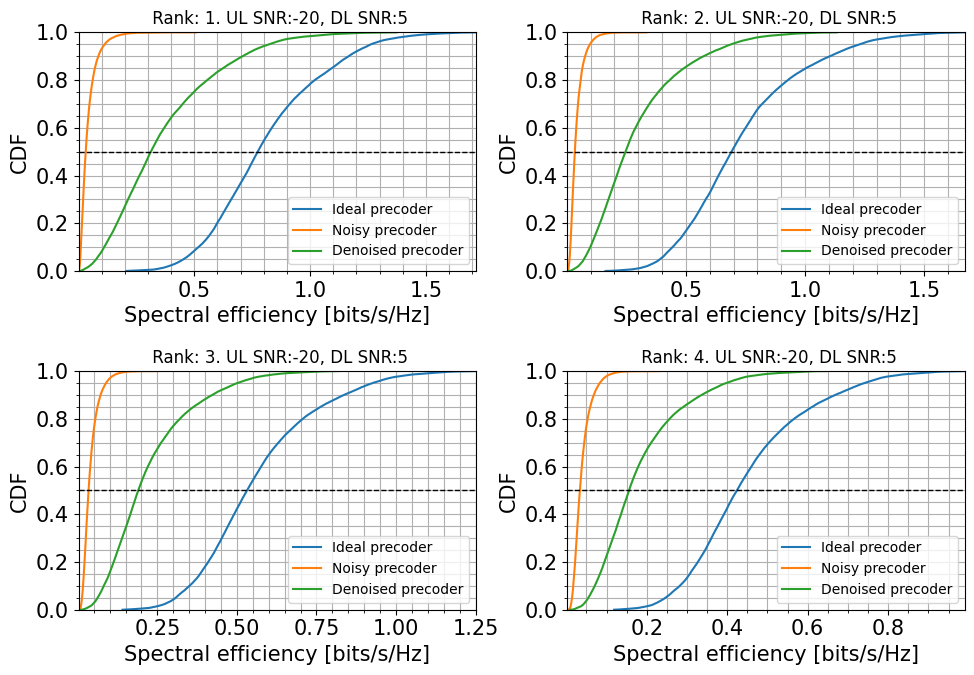

In [40]:
UL_SNR_db = -20
DL_SNR_db = 5

N = get_noise(H, SNR_dB=UL_SNR_db)
W = get_svd_precoder(H, max_sim_rank = 4)
W_noisy = get_svd_precoder(H+N, max_sim_rank = 4)
W_hat = get_svd_precoder(hard_window(H+N), max_sim_rank = 4)

plt.figure(figsize=(10, 7))
for i_rank in range(1, 5):
    plt.subplot(2, 2, i_rank)
    C = su_rate(H, W[..., :i_rank], DL_SNR_db)
    C_noisy = su_rate(H, W_noisy[..., :i_rank], DL_SNR_db)
    C_hat = su_rate(H, W_hat[...,:i_rank], DL_SNR_db)
    
    plt.plot(np.sort(C.ravel()), np.linspace(0, 1, len(C.ravel())), label = 'Ideal precoder')
    plt.plot(np.sort(C_noisy.ravel()), np.linspace(0, 1, len(C.ravel())), label = 'Noisy precoder')
    plt.plot(np.sort(C_hat.ravel()), np.linspace(0, 1, len(C.ravel())), label = 'Denoised precoder')
    plt.minorticks_on()
    plt.grid(which ='both')
    plt.xlabel('Spectral efficiency [bits/s/Hz]')
    plt.ylabel('CDF')
    plt.title(f' Rank: {i_rank}. UL SNR:{UL_SNR_db}, DL SNR:{DL_SNR_db}', fontsize = 12)
    plt.margins(x=0, y=0)
    plt.legend(fontsize = 10)
    plt.axhline(0.5, color="k", linestyle="--", linewidth=1)
plt.tight_layout()

In [41]:
def circular_energy_window(pdp, frac=0.99, min_len=6, max_len=None):
    """
    Smallest circular window that contains at least frac of total PDP energy.
    Returns start index and length.
    """
    K = len(pdp)
    p = np.real(pdp).copy()
    p = np.maximum(p, 0)
    p = p / (np.sum(p) + 1e-12)

    if max_len is None:
        max_len = K

    p2 = np.concatenate([p, p])
    c = np.concatenate([[0.0], np.cumsum(p2)])

    best_len = K + 1
    best_start = 0

    for s in range(K):
        target = c[s] + frac
        e = np.searchsorted(c, target, side='left')
        L = e - s
        if min_len <= L <= max_len and L < best_len:
            best_len = L
            best_start = s

    if best_len == K + 1:
        best_len = min(max_len, K)
        best_start = 0

    return best_start, best_len


def make_circular_mask(K, start, length):
    mask = np.zeros(K, dtype=float)
    idx = (start + np.arange(length)) % K
    mask[idx] = 1.0
    return mask


def estimate_delay_mask(H_noisy, frac=0.90, min_len=8, max_len=24):
    """
    Estimate adaptive delay support from averaged PDP,
    after removing a simple noise floor estimate.
    """
    Z = np.fft.ifft(H_noisy, axis=1, norm='ortho')
    pdp = np.mean(np.abs(Z)**2, axis=(0, 2, 3))   # average over time, UE, BS

    # subtract robust noise floor
    noise_floor = np.median(pdp)
    pdp_clean = np.maximum(pdp - noise_floor, 0.0)

    # fallback if everything is too small
    if np.sum(pdp_clean) < 1e-12:
        pdp_clean = pdp.copy()

    start, length = circular_energy_window(
        pdp_clean,
        frac=frac,
        min_len=min_len,
        max_len=max_len
    )

    mask = make_circular_mask(H_noisy.shape[1], start, length)
    return mask, pdp, pdp_clean, start, length

def soft_shrink_singular_values(S, tau):
    return np.maximum(S - tau, 0.0)


def adaptive_delay_soft_lowrank(H_noisy, frac=0.90, tau_scale=1.0, max_len=24):
    T, K, M, N = H_noisy.shape
    Z = np.fft.ifft(H_noisy, axis=1, norm='ortho')

    mask, pdp, pdp_clean, start, length = estimate_delay_mask(
        H_noisy,
        frac=frac,
        min_len=8,
        max_len=max_len
    )

    Zhat = np.zeros_like(Z)
    kept_bins = np.where(mask > 0.5)[0]

    for t in range(T):
        for k in kept_bins:
            Htk = Z[t, k]
            U, S, Vh = np.linalg.svd(Htk, full_matrices=False)

            sigma_noise = np.median(S)
            tau = tau_scale * sigma_noise
            S_shrunk = np.maximum(S - tau, 0.0)

            if np.all(S_shrunk < 1e-12):
                S_shrunk[0] = S[0]

            Zhat[t, k] = U @ np.diag(S_shrunk) @ Vh

    H_hat = np.fft.fft(Zhat, axis=1, norm='ortho')
    return H_hat, mask, pdp, pdp_clean, start, length

### My proposed Method

  0%|          | 0/3 [00:00<?, ?it/s]

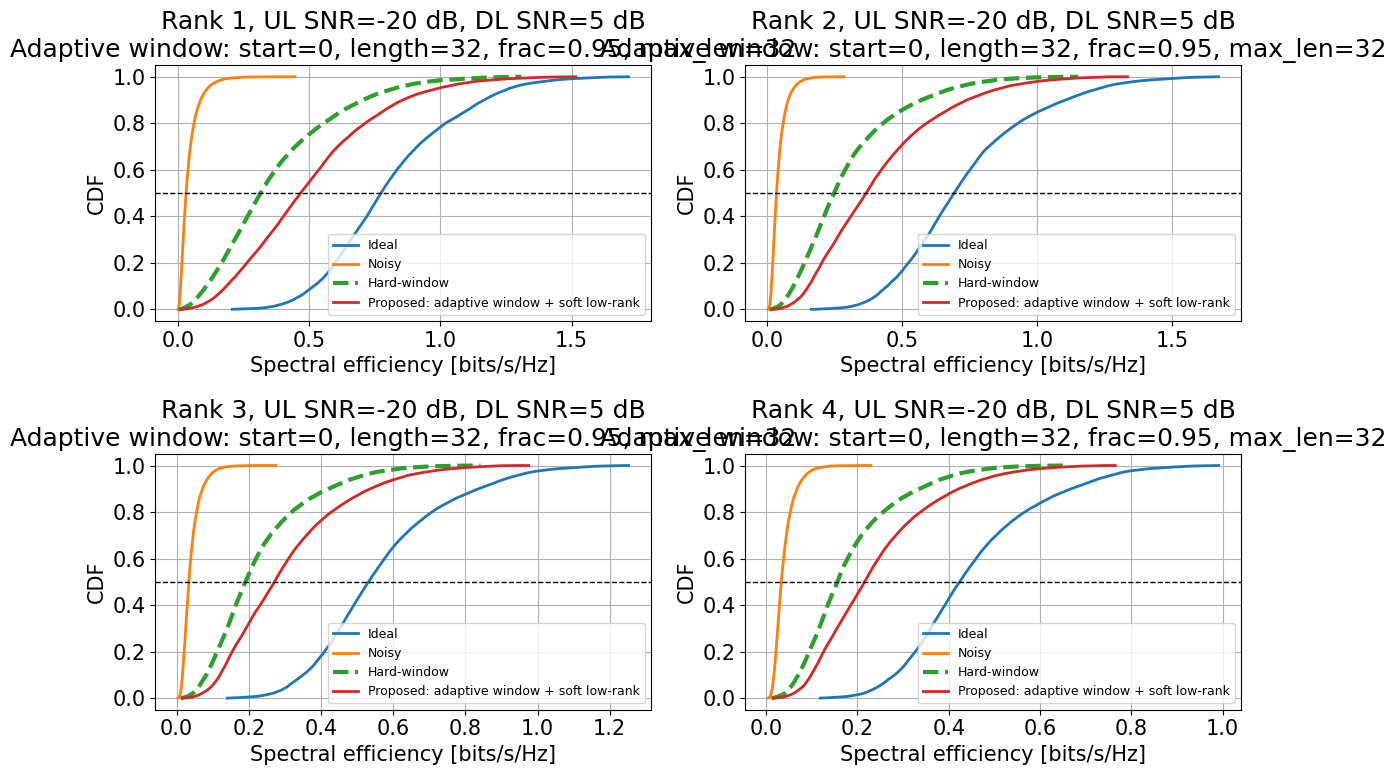

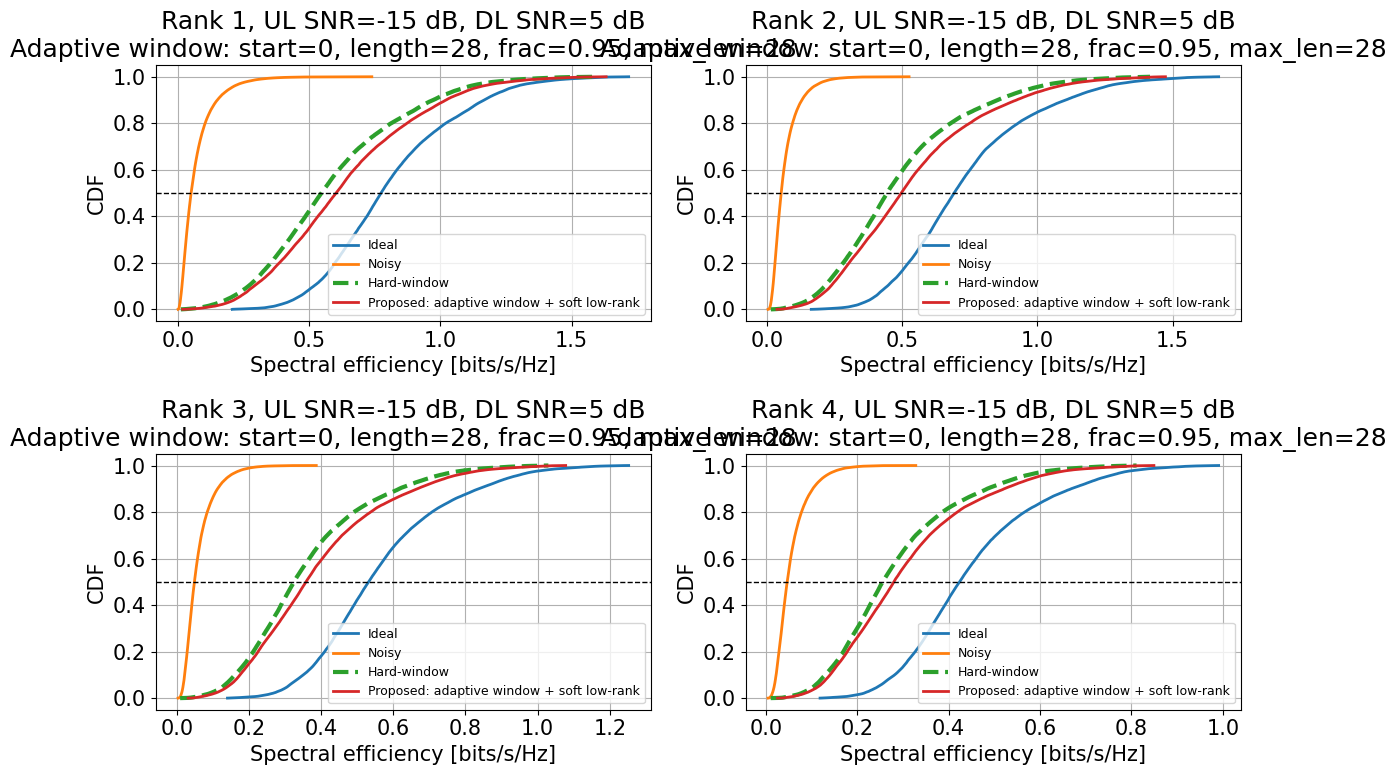

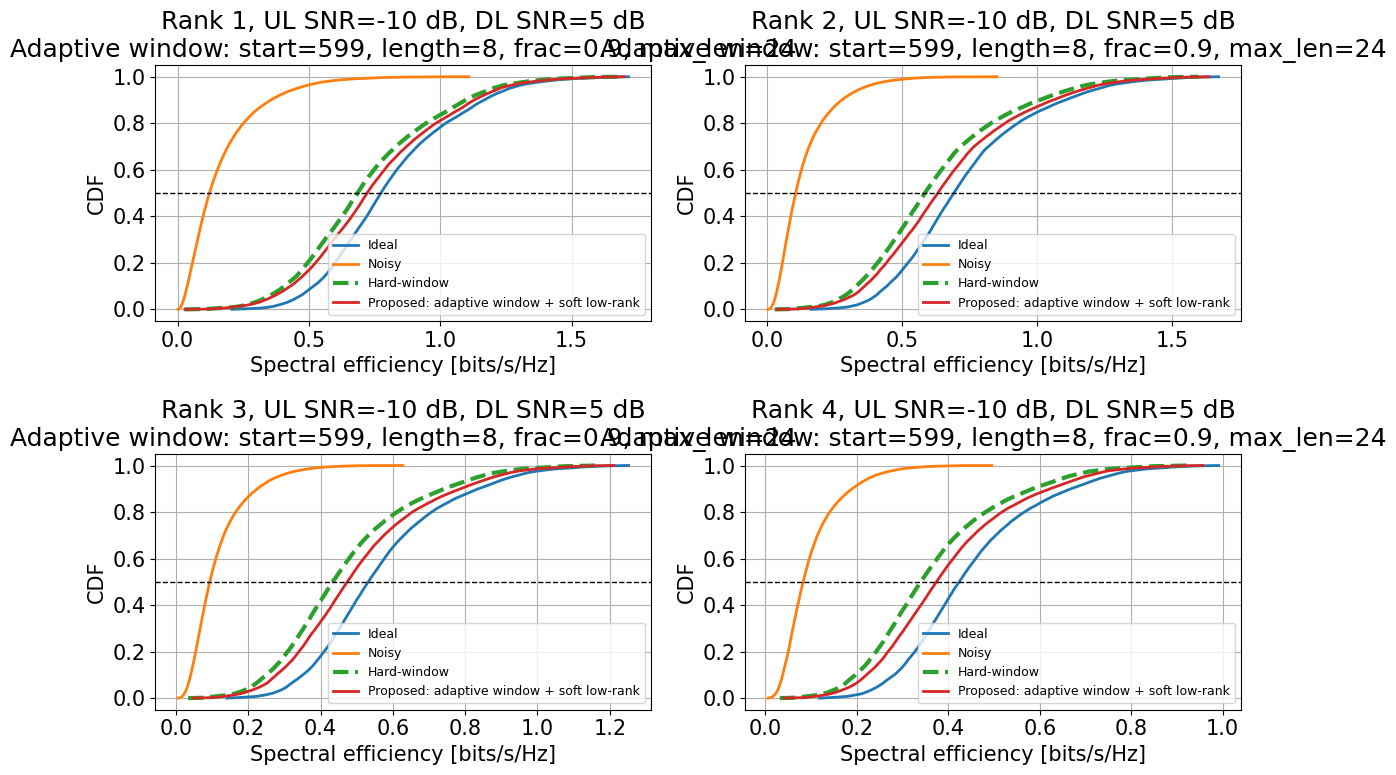

In [ ]:
def median_rate(C):
    return np.median(np.ravel(C))

UL_SNR_list = [-20, -15, -10]
DL_SNR_db = 5

for UL_SNR_db in tqdm(UL_SNR_list):
    N = get_noise(H, SNR_dB=UL_SNR_db)
    H_noisy = H + N

    H_hw = hard_window(H_noisy)

    # SNR-dependent adaptive settings
    if UL_SNR_db == -20:
        frac_use = 0.95
        max_len_use = 32
        tau_scale = 1.0
    elif UL_SNR_db == -15:
        frac_use = 0.95
        max_len_use = 28
        tau_scale = 0.8
    else:  # UL_SNR_db == -10
        frac_use = 0.90
        max_len_use = 24
        tau_scale = 0.5

    H_prop, mask, pdp, pdp_clean, start, length = adaptive_delay_soft_lowrank(
        H_noisy,
        frac=frac_use,
        tau_scale=tau_scale,
        max_len=max_len_use
    )

    W_ideal = get_svd_precoder(H, 4)
    W_noisy = get_svd_precoder(H_noisy, 4)
    W_hw    = get_svd_precoder(H_hw, 4)
    W_prop  = get_svd_precoder(H_prop, 4)

    plt.figure(figsize=(12, 8))

    for i_rank in range(1, 5):
        plt.subplot(2, 2, i_rank)

        C_ideal = su_rate(H, W_ideal[..., :i_rank], DL_SNR_db)
        C_noisy = su_rate(H, W_noisy[..., :i_rank], DL_SNR_db)
        C_hw    = su_rate(H, W_hw[..., :i_rank], DL_SNR_db)
        C_prop  = su_rate(H, W_prop[..., :i_rank], DL_SNR_db)

        curves = [
            (C_ideal, 'Ideal', dict(linewidth=2)),
            (C_noisy, 'Noisy', dict(linewidth=2)),
            (C_hw, 'Hard-window', dict(linewidth=3, linestyle='--')),
            (C_prop, 'Proposed: adaptive window + soft low-rank', dict(linewidth=2))
        ]

        for data, label, style in curves:
            x, y = empirical_cdf(data)
            plt.plot(x, y, label=label, **style)

        plt.axhline(0.5, color='k', linestyle='--', linewidth=1)
        plt.grid(True, which='both')
        plt.xlabel('Spectral efficiency [bits/s/Hz]')
        plt.ylabel('CDF')
        plt.title(
            f'Rank {i_rank}, UL SNR={UL_SNR_db} dB, DL SNR={DL_SNR_db} dB\n'
            f'Adaptive window: start={start}, length={length}'
        )
        plt.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

In [43]:
rows = []
UL_SNR_list = [-20, -15, -10]
DL_SNR_db = 5

for UL_SNR_db in UL_SNR_list:
    N = get_noise(H, SNR_dB=UL_SNR_db)
    H_noisy = H + N

    H_hw = hard_window(H_noisy)

    # SNR-dependent adaptive settings
    if UL_SNR_db == -20:
        frac_use = 0.95
        max_len_use = 32
        tau_scale = 1.0
    elif UL_SNR_db == -15:
        frac_use = 0.95
        max_len_use = 28
        tau_scale = 0.8
    else:  # UL_SNR_db == -10
        frac_use = 0.90
        max_len_use = 24
        tau_scale = 0.5

    H_prop, _, _, _, _, _ = adaptive_delay_soft_lowrank(
        H_noisy,
        frac=frac_use,
        tau_scale=tau_scale,
        max_len=max_len_use
    )

    W_ideal = get_svd_precoder(H, 4)
    W_noisy = get_svd_precoder(H_noisy, 4)
    W_hw    = get_svd_precoder(H_hw, 4)
    W_prop  = get_svd_precoder(H_prop, 4)

    for rank in [1, 2, 3, 4]:
        C_ideal = su_rate(H, W_ideal[..., :rank], DL_SNR_db)
        C_noisy = su_rate(H, W_noisy[..., :rank], DL_SNR_db)
        C_hw    = su_rate(H, W_hw[..., :rank], DL_SNR_db)
        C_prop  = su_rate(H, W_prop[..., :rank], DL_SNR_db)

        rows.append([
            UL_SNR_db,
            rank,
            median_rate(C_ideal),
            median_rate(C_noisy),
            median_rate(C_hw),
            median_rate(C_prop)
        ])

import pandas as pd

df = pd.DataFrame(rows, columns=[
    'UL_SNR_dB', 'Rank', 'Ideal', 'Noisy', 'HardWindow', 'Proposed'
])

print(df)

print("\nImprovement of Proposed over HardWindow:")
df_improve = df.copy()
df_improve['Delta'] = df_improve['Proposed'] - df_improve['HardWindow']
print(df_improve[['UL_SNR_dB', 'Rank', 'HardWindow', 'Proposed', 'Delta']])

    UL_SNR_dB  Rank     Ideal     Noisy  HardWindow  Proposed
0         -20     1  0.774179  0.031540    0.314371  0.466915
1         -20     2  0.691112  0.033499    0.246953  0.363909
2         -20     3  0.531731  0.033842    0.190822  0.269763
3         -20     4  0.424087  0.033484    0.156596  0.214701
4         -15     1  0.774179  0.051080    0.545588  0.600248
5         -15     2  0.691112  0.050942    0.442340  0.491829
6         -15     3  0.531731  0.048737    0.325021  0.356638
7         -15     4  0.424087  0.046689    0.255865  0.279297
8         -10     1  0.774179  0.121548    0.683980  0.720572
9         -10     2  0.691112  0.106601    0.584551  0.632455
10        -10     3  0.531731  0.092929    0.433226  0.473537
11        -10     4  0.424087  0.082423    0.339656  0.374198

Improvement of Proposed over HardWindow:
    UL_SNR_dB  Rank  HardWindow  Proposed     Delta
0         -20     1    0.314371  0.466915  0.152544
1         -20     2    0.246953  0.363909  0.116

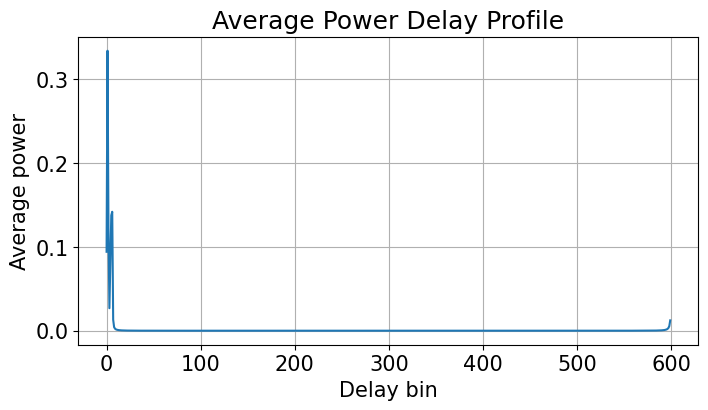

In [44]:
def compute_pdp(H_in):
    Z = np.fft.ifft(H_in, axis=1, norm='ortho')
    pdp = np.mean(np.abs(Z)**2, axis=(0, 2, 3))   # average over time, UE, BS
    return pdp

pdp = compute_pdp(H)
plt.figure(figsize=(8,4))
plt.plot(pdp)
plt.title('Average Power Delay Profile')
plt.xlabel('Delay bin')
plt.ylabel('Average power')
plt.grid(True)
plt.show()

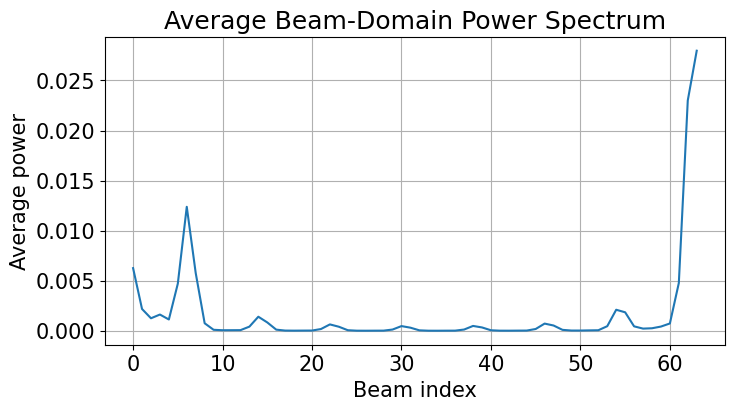

In [45]:
def compute_beam_spectrum(H_in):
    Hb = np.fft.fft(H_in, axis=-1, norm='ortho')
    spec = np.mean(np.abs(Hb)**2, axis=(0, 1, 2))
    return spec

beam_spec = compute_beam_spectrum(H)
plt.figure(figsize=(8,4))
plt.plot(beam_spec)
plt.title('Average Beam-Domain Power Spectrum')
plt.xlabel('Beam index')
plt.ylabel('Average power')
plt.grid(True)
plt.show()

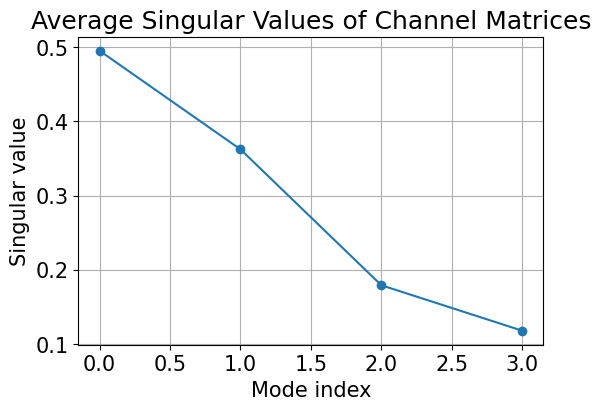

In [46]:
def avg_singular_values(H_in, n_samples=200):
    T, K = H_in.shape[:2]
    sv_all = []
    for _ in range(n_samples):
        t = np.random.randint(T)
        k = np.random.randint(K)
        s = np.linalg.svd(H_in[t, k], compute_uv=False)
        sv_all.append(s)
    return np.mean(np.array(sv_all), axis=0)

sv = avg_singular_values(H)
plt.figure(figsize=(6,4))
plt.plot(sv, marker='o')
plt.title('Average Singular Values of Channel Matrices')
plt.xlabel('Mode index')
plt.ylabel('Singular value')
plt.grid(True)
plt.show()

## 🔴 Tasks

1. Implement a function for calculating the instantaneous spectral efficiency $C(k,t)$ and the corresponding empirical CDF over all available time–frequency samples.

2. Review modern approaches to MIMO channel denoising and summarize the main ideas behind the selected methods.  

3. Design and implement a channel denoising method that outperforms the provided hard-window baseline.

   For evaluation, consider the following uplink SNR values:

   $$
   \mathrm{SNR}_{\mathrm{UL}} \in \{-20,\,-15,\,-10\}\ \mathrm{dB},
   $$

   and fix the downlink SNR to

   $$
   \mathrm{SNR}_{\mathrm{DL}} = 5\ \mathrm{dB}.
   $$

   Compare your method against the baseline using the spectral efficiency metric.

4. Provide an interpretation of the algorithm in terms of channel structure and propagation properties.  
   Your analysis may include, for example: power delay profile (PDP), angular or beam-domain spectrum, channel rank and other relevant channel features.

5. Critically evaluate the proposed method and discuss its main strengths and weaknesses.  

6. Summarize your methodology, experiments, results, and conclusions in the form of a short report written in a **scientific paper style**.